# Florentine families

In [1]:
import sys
import os
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import jax
import jax.numpy as jnp
import jax.scipy as jsp

## Network

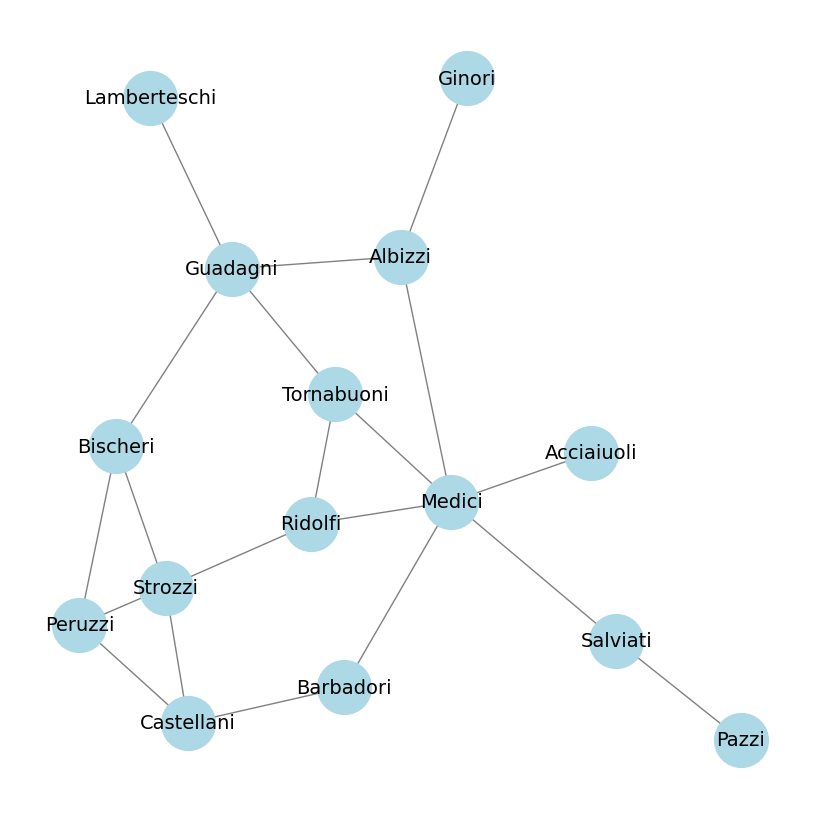

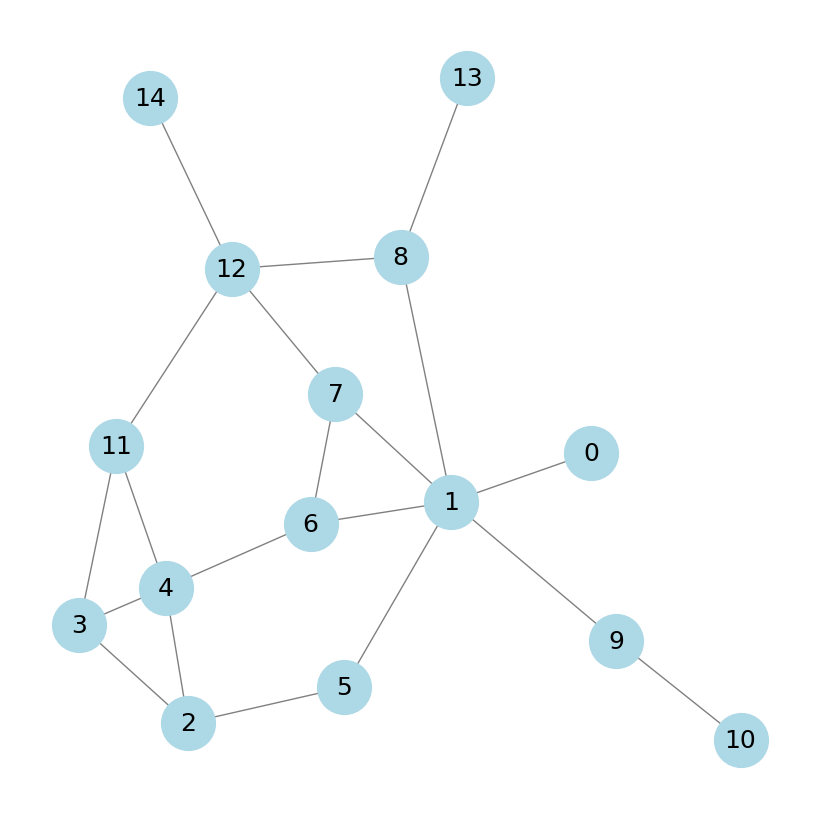

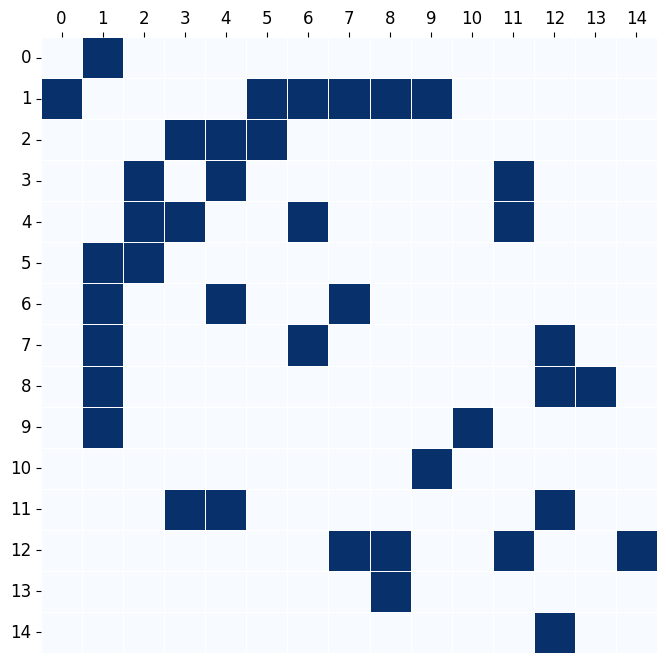

In [2]:
G = nx.florentine_families_graph()
pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(8,8))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=14)
#plt.title("Florentine Families network")
plt.show()

G = nx.florentine_families_graph()
node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
plt.figure(figsize=(8,8))
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
nx.draw(G,  pos=pos_relabel, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=18)
#plt.title("Florentine Families network with relabeled nodes")
plt.show()
#print("Map from original nodes to new nodes:")
#print(node_mapping)

Y = nx.to_numpy_array(G, dtype=float)
plt.figure(figsize=(8,8))
sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top() 
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=12)
#plt.title("Sociomatrix for Florentine families")
plt.show() 

## Code

### Geometry

Base

In [3]:
class Geometry:
    def distance(self, zi, zj):
        raise NotImplementedError
    def distance_matrix(self, Z):
        raise NotImplementedError
    def project_to_tangent(self, z, v):
        raise NotImplementedError
    def project_to_domain(self, z):
        raise NotImplementedError
    def logaritmic_map(self, z, zp):
        raise NotImplementedError
    def exponential_map(self, z, v):
        raise NotImplementedError
    def identifiability_transform(self, Z, Z_ref):
        raise NotImplementedError
    def sample_uniform_Z(self, n:int, seed:int):
        raise NotImplementedError

Simplex

In [4]:
class Simplex:
    def __init__(self, n):
        self.n = n
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.exponential_map   = jax.jit(self._exponential_map)

    # Tangent projection
    def _project_to_tangent(self, xi, v):
        mean_v = jnp.mean(v)
        return v - mean_v

    # Projection to simplex
    def _project_to_domain(self, xi):
        xi = jnp.maximum(xi, 1e-12)
        return self.n * xi / jnp.sum(xi)

    # Exponential map 
    def _exponential_map(self, xi, v):
        xi_new = xi * jnp.exp(v)
        return self.n * xi_new / jnp.sum(xi_new)

Euclidean

In [5]:
class EuclideanGeometry(Geometry):
    def __init__(self, d, D=None):
        self.d = d
        self.D = D  
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))

    # distance 
    def _distance(self, zi, zj):
        diff = zi - zj
        return jnp.sqrt(jnp.sum(diff**2) + 1e-12)
    
    # distance matrix
    def _distance_matrix(self, Z):
        diff = Z[:, None, :] - Z[None, :, :]
        return jnp.sqrt(jnp.sum(diff**2, axis=-1) + 1e-12)
    
    # tangent projection 
    def _project_to_tangent(self, z, v):
        return v
    
    # domain projection
    def _project_to_domain(self, z):
        if self.D is None:
            return z
        radius = self.D / 2.0
        norm = jnp.linalg.norm(z)
        factor = jnp.minimum(1.0, radius / (norm + 1e-12))
        return z * factor
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        v = zp - z
        return v
    
    # exponential map 
    def _exponential_map(self, z, v):
        y = z + v
        return y 
    
    # identifiability
    def _identifiability_transform(self, Z, Z_ref):
        """
        Align latent positions Z to a reference configuration Z_ref
        using the orthogonal Procrustes transformation.
        Parameters
        ----------
        Z : array (n,d)
            Current latent positions.
        Z_ref : array (n,d)
            Reference latent positions.
        Returns
        -------
        Z_aligned : array (n,d)
            Aligned configuration.
        """
        # center configurations
        Z_mean = jnp.mean(Z, axis=0, keepdims=True)
        Z_ref_mean = jnp.mean(Z_ref, axis=0, keepdims=True)
        Zc = Z - Z_mean
        Z_refc = Z_ref - Z_ref_mean
        # cross-covariance matrix
        M = Zc.T @ Z_refc
        # SVD
        U, _, Vt = jnp.linalg.svd(M, full_matrices=False)
        # optimal orthogonal transformation
        R = Vt.T @ U.T
        # avoid improper rotations (reflection)
        detR = jnp.linalg.det(R)
        correction = jnp.eye(self.d)
        correction = correction.at[-1, -1].set(jnp.sign(detR))
        R = Vt.T @ correction @ U.T
        # aligned configuration
        Z_aligned = Zc @ R
        # recenter to reference centroid
        Z_aligned = Z_aligned + Z_ref_mean
        return Z_aligned
    
    # sampling
    def sample_uniform_Z(self, n: int, key):
        if self.D is None:
            return jax.random.normal(key, shape=(n, self.d))
        R = self.D / 2.0
        key1, key2 = jax.random.split(key)
        # random directions on sphere
        X = jax.random.normal(key1, shape=(n, self.d))
        norms = jnp.linalg.norm(X, axis=1, keepdims=True) + 1e-12
        directions = X / norms
        # radial law for uniform volume measure in ball
        u = jax.random.uniform(key2, shape=(n, 1))
        radii = R * (u ** (1.0 / self.d))
        return directions * radii

Spherical

In [6]:
class SphericalGeometry(Geometry):
    def __init__(self, d, R=1.0, D = jnp.pi):
        self.d = d
        self.D = D
        self.R = R
        self.R = D / jnp.pi
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))
    
    # distance on S^d(R) 
    def _distance(self, zi, zj):
        dot = jnp.dot(zi, zj) / (self.R**2)
        dot = jnp.clip(dot, -1.0 + 1e-7, 1.0 - 1e-7)
        return self.R * jnp.arccos(dot)
    
    # distance matrix 
    def _distance_matrix(self, Z):
        dot = (Z @ Z.T) / (self.R**2)
        dot = jnp.clip(dot, -1.0 + 1e-7, 1.0 - 1e-7)
        return self.R * jnp.arccos(dot)
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        dot = jnp.clip(jnp.dot(z, zp) / (self.R**2), -1.0 + 1e-12, 1.0 - 1e-12)
        theta = jnp.arccos(dot)
        sin_theta = jnp.sin(theta)
        factor = theta / (sin_theta + 1e-12)
        v = factor * (zp - dot * z)
        return v
    
    # projection to tangent space 
    def _project_to_tangent(self, z, v):
        return v - (jnp.dot(z, v) / (self.R**2)) * z
    
    # domain projection
    def _project_to_domain(self, z):
        norm = jnp.linalg.norm(z) + 1e-12
        return self.R * z / norm
  
    
    # exponential map 
    def _exponential_map(self, z, v):
        norm_v = jnp.linalg.norm(v)
        eps = 1e-12
        coef1 = jnp.cos(norm_v / self.R)
        coef2 = jnp.sin(norm_v / self.R) / (norm_v + eps)
        y = coef1 * z + coef2 * v
        return y    
    
    # identifiability 
    # identifiability on S^d(R)
    def _identifiability_transform(self, Z, Z_ref):
        # cross-covariance matrix
        M = Z.T @ Z_ref
        # SVD decomposition
        U, _, Vt = jnp.linalg.svd(M, full_matrices=False)
        # optimal orthogonal matrix
        Q = Vt.T @ U.T
        # avoid reflections
        detQ = jnp.linalg.det(Q)
        correction = jnp.eye(self.d + 1)
        correction = correction.at[-1, -1].set(jnp.sign(detQ))
        Q = Vt.T @ correction @ U.T
        # rotate configuration
        Z_aligned = Z @ Q
        # numerical reprojection onto sphere
        norms = jnp.linalg.norm(Z_aligned, axis=1, keepdims=True) + 1e-12
        Z_aligned = self.R * Z_aligned / norms
        return Z_aligned
    
    #sampling
    def sample_uniform_Z(self, n: int, key):
        X = jax.random.normal(key, shape=(n, self.d + 1))
        norms = jnp.linalg.norm(X, axis=1, keepdims=True) + 1e-12
        Z = self.R * X / norms
        return Z

Hyperbolic

In [7]:
class HyperbolicGeometry(Geometry):
    def __init__(self, d, R=1.0, D=None):
        self.d = d
        self.R = R
        self.D = D
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))

    # Lorentz inner product 
    def _lorentz_inner(self, zi, zj):
        return jnp.dot(zi[:-1], zj[:-1]) - zi[-1] * zj[-1]
    
    # distance
    def _distance(self, zi, zj):
        inner = self._lorentz_inner(zi, zj)
        x = -inner / (self.R**2)
        x = jnp.clip(x, 1.0 + 1e-7, None)
        return self.R * jnp.arccosh(x)
    
    # distance matrix
    def _distance_matrix(self, Z):
        spatial = Z[:, :-1]
        time = Z[:, -1]
        inner = spatial @ spatial.T - jnp.outer(time, time)
        x = -inner / (self.R**2)
        x = jnp.maximum(x, 1.0 + 1e-7)
        return self.R * jnp.arccosh(x)
    
    # projection to tangent 
    def _project_to_tangent(self, z, v):
        # T_z H^d = {v : <z,v>_L = 0}
        inner = self._lorentz_inner(z, v)
        return v + (inner / (self.R**2)) * z
    
    # domain projection
    def _project_to_domain(self, z):
        t_max = self.R * jnp.cosh(self.D / (2 * self.R))
        x = z[:-1]
        t = z[-1]
        def inside():
            return z
        def outside():
            norm_x = jnp.linalg.norm(x) + 1e-12
            new_norm = jnp.sqrt(t_max**2 - self.R**2)
            factor = new_norm / norm_x
            x_new = x * factor
            return jnp.concatenate([x_new, jnp.array([t_max])])
        return jax.lax.cond(t <= t_max, inside, outside)
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        dot = self._lorentz_inner(z, zp)
        alpha = -dot  # debe ser ≥ 1
        omega = jnp.arccosh(alpha)
        denom = jnp.sqrt(alpha**2 - 1.0 + 1e-12)
        v = (omega / (denom + 1e-12)) * (zp + (dot / (self.R**2)) * z)
        return self._project_to_tangent(z, v)
    
    # exponential map 
    def _exponential_map(self, z, v):
        norm_v_sq = self._lorentz_inner(v, v)
        norm_v = jnp.sqrt(jnp.maximum(norm_v_sq, 1e-12))
        coef1 = jnp.cosh(norm_v / self.R)
        coef2 = jnp.sinh(norm_v / self.R) / (norm_v + 1e-12)
        z_new = coef1 * z + coef2 * v
        return z_new
    
    # identifiability 
    def _identifiability_transform(self, Z, Z_ref):
        p = self.d + 1
        # Minkowski metric
        J = jnp.eye(p)
        J = J.at[-1, -1].set(-1.0)
        # generalized covariance
        M = Z_ref.T @ J @ Z
        # Euclidean SVD
        U, _, Vt = jnp.linalg.svd(M, full_matrices=False)
        # candidate Lorentz transform
        Q = U @ Vt
        # enforce Lorentz condition approximately
        # Q^T J Q = J
        A = Q.T @ J @ Q
        # symmetric correction
        eigvals, eigvecs = jnp.linalg.eigh(A)
        inv_sqrt = eigvecs @ jnp.diag(1.0 / jnp.sqrt(jnp.abs(eigvals) + 1e-12)) @ eigvecs.T
        Q = Q @ inv_sqrt
        # aligned configuration
        Z_aligned = Z @ Q.T
        # numerical reprojection onto hyperboloid
        spatial = Z_aligned[:, :-1]
        spatial_norm_sq = jnp.sum(spatial**2, axis=1, keepdims=True)
        time = jnp.sqrt(self.R**2 + spatial_norm_sq)
        Z_aligned = jnp.concatenate([spatial, time], axis=1)
        return Z_aligned
    
    # sampling
    def sample_uniform_Z(self, n: int, key):
        assert self.d in [1, 2], "Exact sampler implemented for d=1 or d=2"
        assert self.D is not None, "Hyperbolic sampling requires finite D"

        R = self.R

        if self.d == 1:
            key1, key2 = jax.random.split(key)

            # random direction in {-1,+1}
            direction = jax.random.choice(
                key1,
                jnp.array([-1.0, 1.0]),
                shape=(n, 1)
            )

            # uniform radius in [0, D/2]
            u = jax.random.uniform(key2, shape=(n, 1))
            r = (self.D / 2.0) * u

        elif self.d == 2:
            key1, key2 = jax.random.split(key)

            # angular direction uniformly on circle
            theta = jax.random.uniform(
                key1,
                shape=(n, 1),
                minval=0.0,
                maxval=2.0 * jnp.pi
            )
            direction = jnp.concatenate(
                [jnp.cos(theta), jnp.sin(theta)],
                axis=1
            )

            # exact radial law in H^2
            alpha = 1.0
            u = jax.random.uniform(key2, shape=(n, 1))
            r = (1.0 / alpha) * jnp.arccosh(
                1.0 + u * (jnp.cosh(alpha * (self.D / 2.0)) - 1.0)
            )

        norm = r / R
        cosh_term = jnp.cosh(norm)
        sinh_term = jnp.sinh(norm)

        spatial = R * sinh_term * direction
        time = R * cosh_term

        Z = jnp.concatenate([spatial, time], axis=1)
        return Z

### Likelihood

In [8]:
class LatentSpaceLikelihood:
    def __init__(self, geometry):
        self.geometry = geometry
        self.loglikelihood = jax.jit(self._loglikelihood)
        self.grad_alpha0 = jax.jit(jax.grad(self._loglikelihood, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._loglikelihood, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._loglikelihood, argnums=2))
    # predictor
    def _predictor(self, alpha0, xi, Z):
        D = self.geometry.distance_matrix(Z)
        xi_i = xi[:, None]
        xi_j = xi[None, :]
        S = alpha0 - 0.5 * (xi_i + xi_j) * D
        return S
    # loglikelihood
    def _loglikelihood(self, alpha0, xi, Z, Y):
        S = self._predictor(alpha0, xi, Z)
        mask = jnp.triu(jnp.ones_like(Y), k=1)
        loglik = Y * S - jax.nn.softplus(S)
        return jnp.sum(loglik * mask)
    # gradients
    def gradients(self, alpha0, xi, Z, Y):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z, Y), "xi": self.grad_xi(alpha0, xi, Z, Y), "Z": self.grad_Z(alpha0, xi, Z, Y)}

### Prior

In [9]:
class LatentSpacePrior:
    def __init__(self, geometry, sigma2_alpha0=10.0, a_xi=2.0, fixed_params:dict = {}):
        self.sigma2_alpha0 = sigma2_alpha0
        self.a_xi = a_xi
        self.geometry = geometry
        self.fixed_params = fixed_params
        self.fix_alpha0 = "alpha0" in fixed_params
        if self.fix_alpha0:
            self.alpha0_fixed = self.fixed_params.get("alpha0", None)
        self.fix_xi     = "xi" in fixed_params
        if self.fix_xi:
            self.xi_fixed = self.fixed_params.get("xi", None)
        self.fix_Z      = "Z" in fixed_params
        if self.fix_Z:
            self.Z_fixed = self.fixed_params.get("Z", None)
         
        self.log_prior_density = jax.jit(self._log_prior_density)
        self.grad_alpha0 = jax.jit(jax.grad(self._log_prior_density, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._log_prior_density, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._log_prior_density, argnums=2))
        

    #  log prior 
    def _log_prior_density(self, alpha0, xi, Z):
        logp = 0.0
        # alpha0 ~ N(0, sigma2)
        if not self.fix_alpha0:
            logp += -0.5 * (jnp.log(self.sigma2_alpha0) + alpha0**2 / self.sigma2_alpha0)
        # xi ~ Dirichlet 
        if not self.fix_xi:
            xi_safe = jnp.clip(xi, 1e-12, 1e6)
            logp += jnp.sum((self.a_xi - 1.0) * jnp.log(xi_safe))
        # Z ~ Uniform
        if not self.fix_Z:
            logp += 0.0
        return logp

    # gradients
    def gradients(self, alpha0, xi, Z):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z),"xi": self.grad_xi(alpha0, xi, Z),"Z": self.grad_Z(alpha0, xi, Z)}

    # sampling
    def sample(self, n, seed=42):
        key = jax.random.PRNGKey(seed)
        keys = jax.random.split(key, 3)
        # alpha0
        if self.fix_alpha0:
            alpha0 = self.alpha0_fixed
        else:
            alpha0 = jnp.sqrt(self.sigma2_alpha0) * jax.random.normal(keys[0])
        # xi
        if self.fix_xi:
            xi = self.xi_fixed
            assert xi.shape[0] == n, "xi hasn't correct dimension"
        else:
            a_vec = jnp.ones(n) * self.a_xi
            xi = jax.random.dirichlet(keys[1], a_vec)
            xi = n * xi
        # Z
        if self.fix_Z:
            Z = self.Z_fixed
            assert Z.shape == (n, self.geometry.d), "Z hasn't correct dimension"
        else:
            Z = self.geometry.sample_uniform_Z(n, keys[2])
        return alpha0, xi, Z

### Posterior

In [15]:
class LatentSpacePosterior:
    def __init__(self, likelihood, prior):
        self.likelihood = likelihood
        self.prior = prior
        self.log_posterior = jax.jit(self._log_posterior)
        self.grad_alpha0 = jax.jit(jax.grad(self._log_posterior, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._log_posterior, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._log_posterior, argnums=2))
    # log posterior 
    def _log_posterior(self, alpha0, xi, Z, Y):
        loglik = self.likelihood.loglikelihood(alpha0, xi, Z, Y)
        logprior = self.prior.log_prior_density(alpha0, xi, Z)
        return loglik + logprior   
    # gradients
    def gradients(self, alpha0, xi, Z, Y):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z, Y),
            "xi":     self.grad_xi(alpha0, xi, Z, Y),
            "Z":      self.grad_Z(alpha0, xi, Z, Y)}

### Model

In [11]:
class LatentSpaceModel:
    def __init__(self, Y, geometry, fixed_params: dict = {}):
        self.Y = Y
        self.geometry = geometry
        self.d = self.geometry.d
        self.fixed_params = fixed_params
        self.prior = LatentSpacePrior(geometry = self.geometry, fixed_params = self.fixed_params)
        self.likelihood = LatentSpaceLikelihood(geometry= self.geometry)
        self.posterior = LatentSpacePosterior(likelihood=self.likelihood, prior=self.prior)
        self.weights = Simplex(n = self.Y.shape[0])
        self.latent_params = {}
        self.init_params = {}
        self.simulated = {}
        self.inferred = {}
    def get_estimation_dict(self):
        latent = ["alpha0", "xi", "Z"]
        return {k: None for k in latent if k not in self.fixed_params}
    def get_params(self):
        return {**self.latent_params, **self.fixed_params}
    def initialize_from_prior(self, n, seed=42):
        alpha0, xi, Z = self.prior.sample(n, seed)
        sampled = {"alpha0": alpha0, "xi": xi, "Z": Z}
        self.latent_params = {
            k: v for k, v in sampled.items()
            if k not in self.fixed_params
        }
        self.init_params = self.get_params().copy()
        return self.get_params()
    def simulate_network(self, key):
        p = self.get_params()
        alpha0 = p["alpha0"]
        xi = p["xi"]
        Z = p["Z"]
        D = self.geometry.distance_matrix(Z)
        S = alpha0 - 0.5 * (xi[:, None] + xi[None, :]) * D
        P = jax.nn.sigmoid(S)
        Y = jax.random.bernoulli(key, P)
        self.simulated = {"Z": Z, "D": D, "P": P, "Y": Y}
        return Y
    
    def log_likelihood(self):
        p = self.get_params()
        return self.likelihood.loglikelihood(
            p["alpha0"], p["xi"], p["Z"], self.Y
        )

    def log_prior(self):
        p = self.get_params()
        return self.prior.log_prior_density(
            p["alpha0"], p["xi"], p["Z"]
        )

    def log_posterior(self):
        p = self.get_params()
        return self.posterior.log_posterior(
            p["alpha0"], p["xi"], p["Z"], self.Y
        )

    def grad_log_likelihood(self):
        p = self.get_params()
        grads = self.likelihood.gradients(p["alpha0"], p["xi"], p["Z"], self.Y)
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}
    
    def grad_log_prior(self):
        p = self.get_params()
        grads = self.prior.gradients(p["alpha0"], p["xi"], p["Z"])
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}
    
    def grad_log_posterior(self):
        p = self.get_params()
        grads = self.posterior.gradients(p["alpha0"], p["xi"], p["Z"], self.Y)
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}

### Inference

In [12]:
class BaseInference:
    def __init__(self, model: LatentSpaceModel):
        self.model = model
        self.history = {
            "params": [],
            "logpost": [],
            "loglik": [],
            "logprior": [],
            "grads": []
        }
        self.result = None

    def fit(self, **kwargs):
        raise NotImplementedError

    def step(self, **kwargs):
        raise NotImplementedError

    def summary(self):
        raise NotImplementedError

#### MAP

In [13]:
class MAPInference(BaseInference): 
    def __init__(self, model, lr=1e-2):
        super().__init__(model)
        self.lr = lr
        self.model.inference_method = "MAP"

    def _save_state(self, grads=None):
        params = self.model.get_params()
        logpost = self.model.log_posterior()
        loglik = self.model.log_likelihood()
        logprior = self.model.log_prior()
        self.history["params"].append({
            k: v.copy() if hasattr(v, "copy") else v
            for k, v in params.items()
        })

        self.history["logpost"].append(float(logpost))
        self.history["loglik"].append(float(loglik))
        self.history["logprior"].append(float(logprior))

        if grads is not None:
            self.history["grads"].append({
                k: v.copy() if hasattr(v, "copy") else v
                for k, v in grads.items()
            })

    def step(self):
        grads = self.model.grad_log_posterior() 
        params = self.model.latent_params
        geom = self.model.geometry

        # alpha0
        if "alpha0" in params:
            params["alpha0"] = params["alpha0"] + self.lr * grads["alpha0"]

        # xi
        if "xi" in params:
            xi = params["xi"]
            gxi = grads["xi"]
            simplex = self.model.weights
            gxi = simplex.project_to_tangent(xi, gxi)
            xi_new = simplex.exponential_map(xi, self.lr * gxi)
            xi_new = simplex.project_to_domain(xi_new)
            params["xi"] = xi_new
            
        # Z
        if "Z" in params:
            Z = params["Z"]
            gZ = grads["Z"]
            Z_new = jax.vmap(geom.exponential_map)(Z, self.lr * gZ)
            Z_new = jax.vmap(geom.project_to_domain)(Z_new)
            params["Z"] = Z_new
        self._save_state(grads)

    def fit(self, n_iter=5000, tol=1e-6, patience=50, verbose=True, use_tqdm=True):
        best = -jnp.inf
        counter = 0
        iterator = tqdm(range(n_iter), desc="MAP") if use_tqdm else range(n_iter)
        for i in iterator:
            self.step()
            current = self.history["logpost"][-1]
            if use_tqdm:
                iterator.set_postfix({
                    "logpost": f"{current:.4f}",
                    "loglik": f"{self.history['loglik'][-1]:.4f}",
                    "logprior": f"{self.history['logprior'][-1]:.4f}",
                    "patience": counter
                })
            if current > best + tol:
                best = current
                counter = 0
            else:
                counter += 1
            if counter >= patience:
                if verbose:
                    msg = f"[STOP] Early stopping at iter {i} (no improvement in {patience} steps)"
                    if use_tqdm:
                        iterator.write(msg)
                    else:
                        print(msg)
                break
        self.result = self.model.get_params()
        return self.result
    
    def fit_multi_start(self, n_starts=25, n_iter=5000, tol=1e-4, patience=50, seeds=None, verbose=True, use_tqdm=True,):
        best_logpost = -jnp.inf
        best_result = None
        all_runs = []
        if seeds is None:
            seeds = list(range(n_starts)) 
        outer_iter = tqdm(range(n_starts), desc="Multi-start") if use_tqdm else range(n_starts)
        for k in outer_iter:
            seed = seeds[k]
            self.model.initialize_from_prior(n=self.model.Y.shape[0], seed=seed)
            self.history = {"params": [], "logpost": [], "loglik": [], "logprior": [], "grads": []}
            self.fit(n_iter=n_iter, tol=tol, patience=patience, verbose=True, use_tqdm=True)
            final_logpost = self.history["logpost"][-1]
            result = self.model.get_params()
            all_runs.append({"seed": seed, "logpost": final_logpost, "params": result})
            if final_logpost > best_logpost:
                best_logpost = final_logpost
                best_result = result
            if use_tqdm:
                outer_iter.set_postfix({"best_logpost": f"{best_logpost:.4f}"})
        self.result = best_result
        self.all_runs = all_runs
        if verbose:
            print(f"\nBest log-posterior: {best_logpost:.4f}")
        return best_result

    def summary(self):
        return {
            "final_params": self.result,
            "final_logpost": self.history["logpost"][-1] if self.history["logpost"] else None,
            "final_loglik": self.history["loglik"][-1] if self.history["loglik"] else None,
            "final_logprior": self.history["logprior"][-1] if self.history["logprior"] else None
        }

Modelo euclideano con pesos

MAP:  35%|███▍      | 17282/50000 [01:04<02:01, 268.74it/s, logpost=-12.1496, loglik=-6.9063, logprior=-5.2433, patience=49]


[STOP] Early stopping at iter 17282 (no improvement in 50 steps)


MAP: 100%|██████████| 50000/50000 [03:08<00:00, 265.92it/s, logpost=-10.3334, loglik=-5.4503, logprior=-4.8831, patience=6] 



Best log-posterior: -10.3334

Log-posterior final: -10.333353042602539
alpha0: 7.551883
xi: [1.2292658  0.41471246 0.97086805 1.0081233  1.1336906  0.72317475
 1.2365488  1.1317228  0.4248072  1.012738   1.456778   0.93013203
 0.7758866  1.1142638  1.4372878 ]
Z: [[  0.8355171  -10.909466  ]
 [  1.171519    -5.5708966 ]
 [-12.40627     -1.5278934 ]
 [-11.846793     3.987916  ]
 [ -8.593244     2.3138392 ]
 [ -9.550567    -8.064532  ]
 [ -3.4435296   -0.20968643]
 [ -0.08215429   1.9474105 ]
 [  9.666075     7.925717  ]
 [  8.931739    -6.3082156 ]
 [ 11.636716    -4.5647416 ]
 [ -7.9567986    7.871718  ]
 [ -0.4625525    8.975933  ]
 [ 11.123044     5.7033234 ]
 [ -0.36113814  12.4947815 ]]


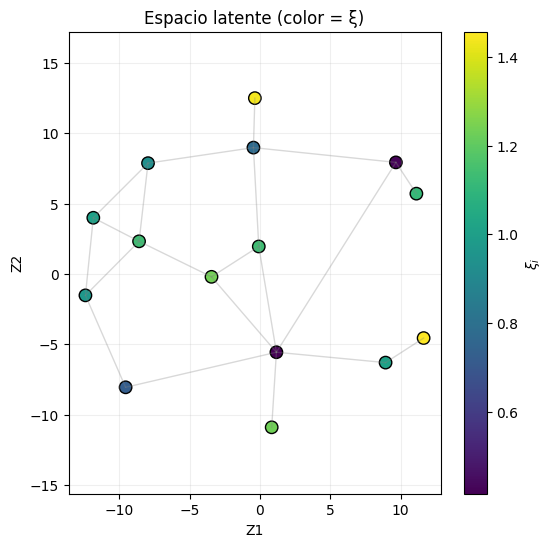

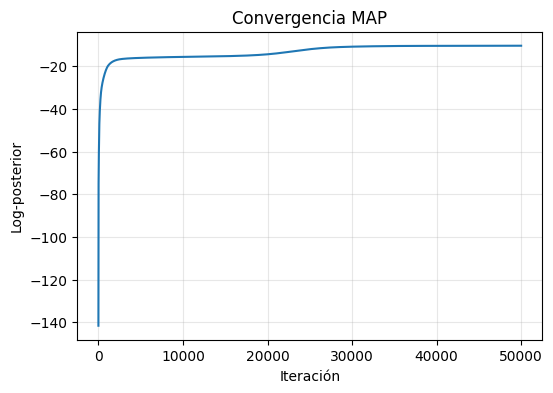

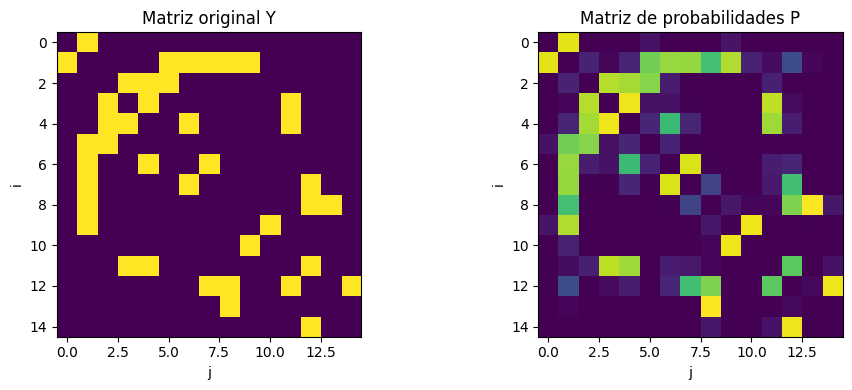

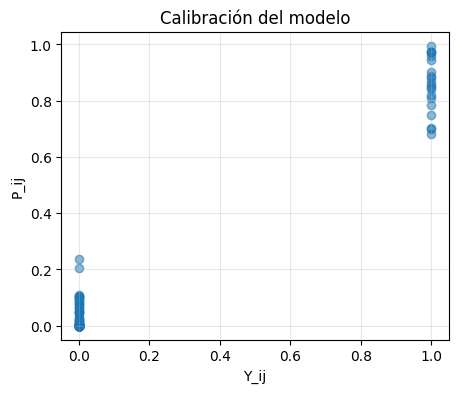

In [52]:

geometry = EuclideanGeometry(d=2, D=25.0)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference( model, lr=1e-2)
result = inference.fit_multi_start(n_starts=2,n_iter=50000, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

#################################################33

Z_np = np.array(Z)
xi_np = np.array(xi)
Y_np = np.array(Y)

plt.figure(figsize=(6,6))

# Dibujar edges
n = Y_np.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if Y_np[i, j] == 1:
            plt.plot(
                [Z_np[i, 0], Z_np[j, 0]],
                [Z_np[i, 1], Z_np[j, 1]],
                color="gray",
                alpha=0.3,
                linewidth=1
            )

# Dibujar nodos
sc = plt.scatter(
    Z_np[:, 0],
    Z_np[:, 1],
    c=xi_np,
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.colorbar(sc, label=r"$\xi_i$")
plt.title("Espacio latente (color = ξ)")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()


from scipy.special import expit

# =========================
# Matriz de probabilidades
# =========================

n = Z_np.shape[0]
P = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            # distancia euclidiana (consistente con tu geometry actual)
            dij = np.linalg.norm(Z_np[i] - Z_np[j])
            
            sij = alpha0 - 0.5 * (xi_np[i] + xi_np[j]) * dij
            P[i, j] = expit(sij)

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

Modelo euclideano sin pesos

MAP:  50%|████▉     | 24859/50000 [01:36<01:37, 257.79it/s, logpost=-15.5443, loglik=-11.8584, logprior=-3.6860, patience=49]


[STOP] Early stopping at iter 24859 (no improvement in 50 steps)


MAP:  33%|███▎      | 16428/50000 [01:00<02:04, 270.73it/s, logpost=-20.4105, loglik=-17.3607, logprior=-3.0498, patience=49]


[STOP] Early stopping at iter 16428 (no improvement in 50 steps)

Best log-posterior: -15.5443

Log-posterior final: -20.410505294799805
alpha0: 7.119913
xi: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Z: [[ -5.9336486   -7.1562147 ]
 [ -3.0461543   -1.284337  ]
 [  0.7301365   10.125262  ]
 [  6.1914654    8.954506  ]
 [  4.6522565    6.9502983 ]
 [ -4.429529     6.8781123 ]
 [  0.5959036    1.5025448 ]
 [  1.2337277   -0.3678211 ]
 [  2.5599935   -7.1848745 ]
 [ -9.421288     0.11397922]
 [-12.46737      0.90259117]
 [  8.920846     4.097625  ]
 [  7.2145505   -2.5338194 ]
 [  3.065141   -11.936301  ]
 [ 11.549446    -4.7812433 ]]


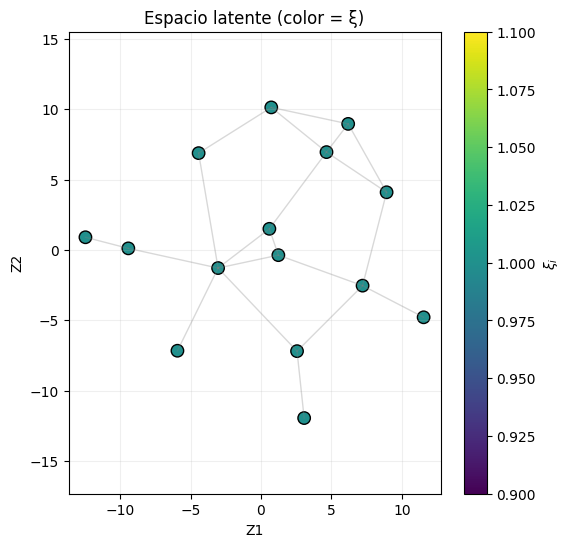

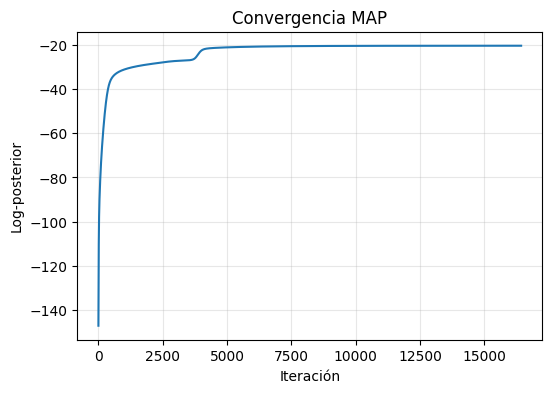

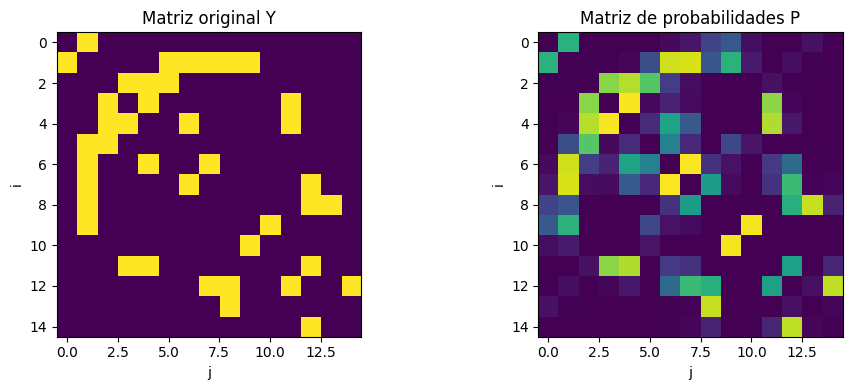

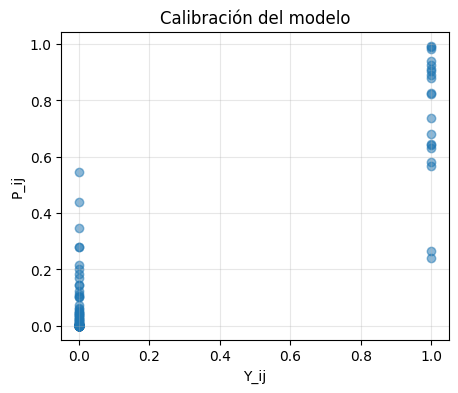

In [53]:

geometry = EuclideanGeometry(d=2, D=25.0)

model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi":jnp.ones(15)})
inference = MAPInference( model, lr=1e-2)
result = inference.fit_multi_start(n_starts=2,n_iter=50000, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

#################################################33

Z_np = np.array(Z)
xi_np = np.array(xi)
Y_np = np.array(Y)

plt.figure(figsize=(6,6))

# Dibujar edges
n = Y_np.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if Y_np[i, j] == 1:
            plt.plot(
                [Z_np[i, 0], Z_np[j, 0]],
                [Z_np[i, 1], Z_np[j, 1]],
                color="gray",
                alpha=0.3,
                linewidth=1
            )

# Dibujar nodos
sc = plt.scatter(
    Z_np[:, 0],
    Z_np[:, 1],
    c=xi_np,
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.colorbar(sc, label=r"$\xi_i$")
plt.title("Espacio latente (color = ξ)")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()


from scipy.special import expit

# =========================
# Matriz de probabilidades
# =========================

n = Z_np.shape[0]
P = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            # distancia euclidiana (consistente con tu geometry actual)
            dij = np.linalg.norm(Z_np[i] - Z_np[j])
            
            sij = alpha0 - 0.5 * (xi_np[i] + xi_np[j]) * dij
            P[i, j] = expit(sij)

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

Modelo esférico con pesos

MAP:  91%|█████████▏| 45654/50000 [03:05<00:17, 246.53it/s, logpost=-13.9686, loglik=-8.6342, logprior=-5.3343, patience=49]


[STOP] Early stopping at iter 45654 (no improvement in 50 steps)


MAP: 100%|██████████| 50000/50000 [03:13<00:00, 257.93it/s, logpost=-17.1619, loglik=-12.7556, logprior=-4.4063, patience=3]



Best log-posterior: -13.9686

Log-posterior final: -17.161888122558594
alpha0: 6.4913754
xi: [1.4484818  0.22508058 1.2523314  1.3301551  1.002542   1.0669798
 0.43881992 0.29683495 0.70229995 1.1276678  1.6295911  1.1262466
 0.6050011  1.3179234  1.4300438 ]
Z: [[ 4.303605    4.466131   -4.985819  ]
 [ 5.493564    0.53207463 -5.73266   ]
 [ 3.1164858  -6.47292     3.422654  ]
 [ 1.533769   -4.537948    6.354551  ]
 [ 3.544181   -3.2295585   6.3509426 ]
 [ 4.097788   -6.6956353  -1.3047374 ]
 [ 7.4647937   0.9830089   2.5760994 ]
 [-6.400735   -4.712692    0.38323367]
 [-2.6772768   7.3329177  -1.5447477 ]
 [-0.06096502 -0.4728096  -7.9434547 ]
 [-2.7149327  -0.83821636 -7.4331875 ]
 [-0.33542842 -1.3937335   7.8275623 ]
 [-4.709714    3.0798333   5.62663   ]
 [-4.1282      6.004761   -3.197898  ]
 [-1.7745051   5.066892    5.8739657 ]]


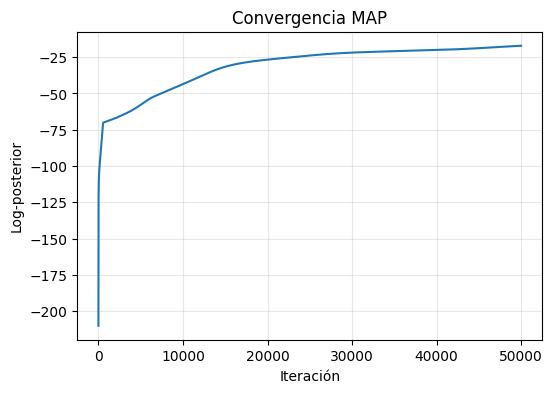

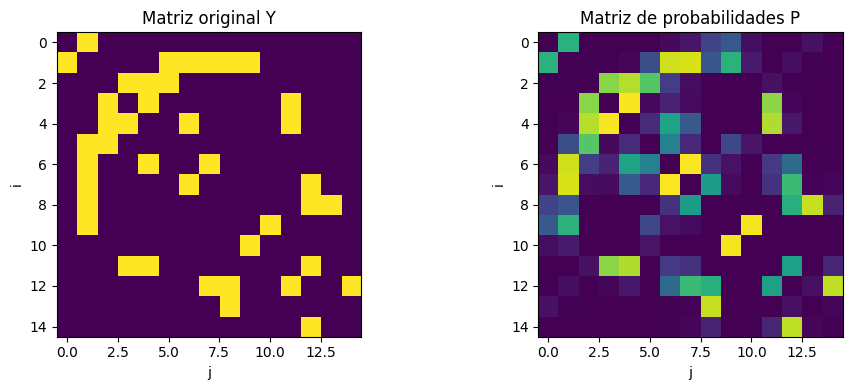

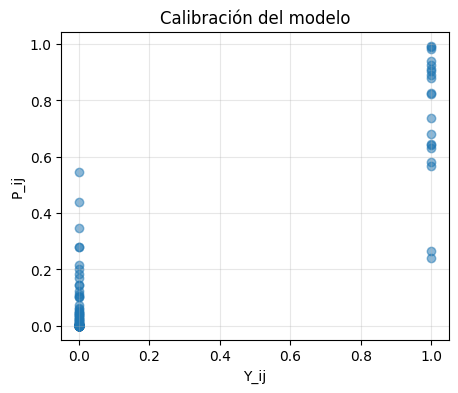

In [55]:

geometry = SphericalGeometry(d=2, D=25.0)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference( model, lr=1e-2)
result = inference.fit_multi_start(n_starts=2,n_iter=50000, tol=1e-3, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

Modelo euclideano sin pesos

MAP:  89%|████████▊ | 44356/50000 [02:48<00:21, 263.72it/s, logpost=-24.0572, loglik=-21.7102, logprior=-2.3471, patience=49]


[STOP] Early stopping at iter 44356 (no improvement in 50 steps)

Best log-posterior: -22.9921

Log-posterior final: -24.057247161865234
alpha0: 6.1507545
xi: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Z: [[ 4.649649   -2.293055   -6.037251  ]
 [-1.62067    -4.860864   -6.088609  ]
 [ 3.0585783  -6.6427464   3.137636  ]
 [ 0.64844584 -5.001637    6.1553946 ]
 [ 1.5673469  -6.743958    3.9227784 ]
 [ 0.1493687  -7.9035664  -0.9149141 ]
 [ 0.7188305  -6.9685082  -3.7747736 ]
 [-4.4488425  -5.7682657  -3.2032254 ]
 [-7.120195   -0.42406803 -3.5282755 ]
 [-1.4427203  -0.04891343 -7.825721  ]
 [-0.46459565  3.2354448  -7.255466  ]
 [-3.4527464  -5.091325    5.048038  ]
 [-7.162771   -3.2857378   1.106514  ]
 [-6.164068    4.4234686  -2.4006107 ]
 [-6.665214    1.0241424   4.225139  ]]


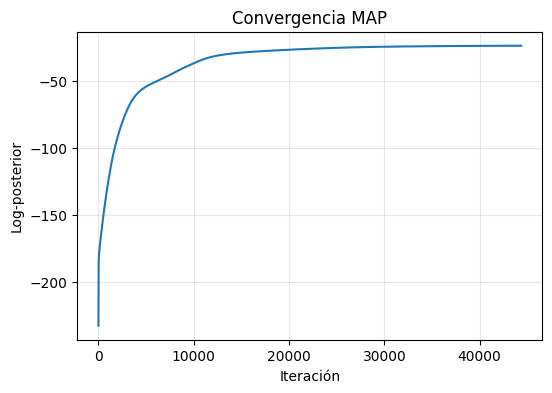

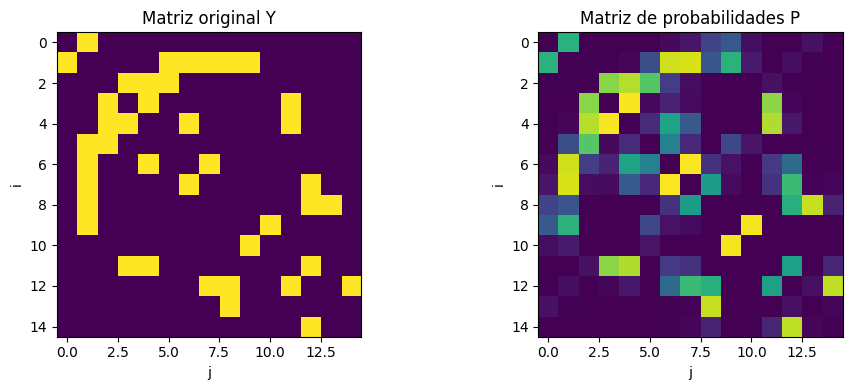

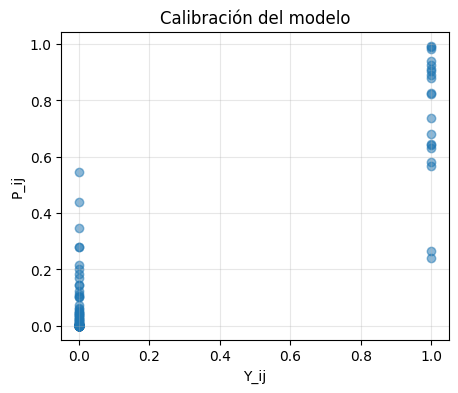

In [54]:

geometry = SphericalGeometry(d=2, D=25.0)

model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi":jnp.ones(15)})
inference = MAPInference( model, lr=1e-2)
result = inference.fit_multi_start(n_starts=2,n_iter=50000, tol=1e-3, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

Modelo hiperbólico con pesos

MAP: 100%|██████████| 50000/50000 [03:16<00:00, 254.66it/s, logpost=-61.8043, loglik=-57.8207, logprior=-3.9837, patience=0]



Best log-posterior: -61.8043

Log-posterior final: -61.80432891845703
alpha0: 0.33707643
xi: [0.59344697 1.1194428  0.22285448 1.4636838  1.0841151  1.4649748
 0.28498057 1.4118854  1.1333674  0.22235057 0.9819128  0.64869356
 0.9949644  2.0961297  1.2771975 ]
Z: [[ 1.3941892  -0.44969243  1.7736615 ]
 [ 1.1680127  -0.03418203  1.5379872 ]
 [-0.1700707   0.51016724  1.1354144 ]
 [-0.17036411  2.2949846   2.5091786 ]
 [-0.6198879   2.2162392   2.5091786 ]
 [ 1.000804   -0.6553169   1.559149  ]
 [-0.7604722   0.0677202   1.2580948 ]
 [-0.06514947 -0.36112538  1.0651275 ]
 [-0.48021647  0.5563684   1.2410464 ]
 [-0.32406396  0.17786808  1.0661174 ]
 [-0.74897236  0.23989116  1.272188  ]
 [-0.2106988   0.26112354  1.0547881 ]
 [-0.61937577  0.4830575   1.2716122 ]
 [-0.04393273  0.03331088  1.0015999 ]
 [ 0.07430377 -0.02959084  1.003539  ]]


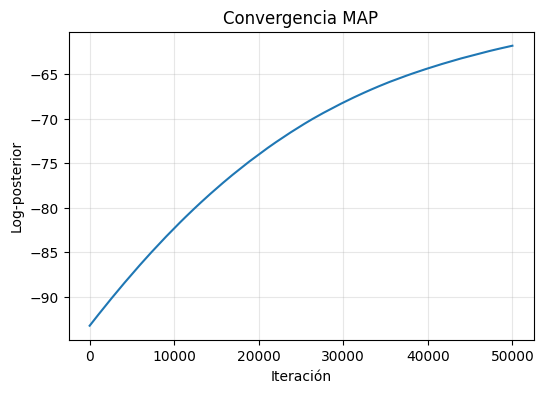

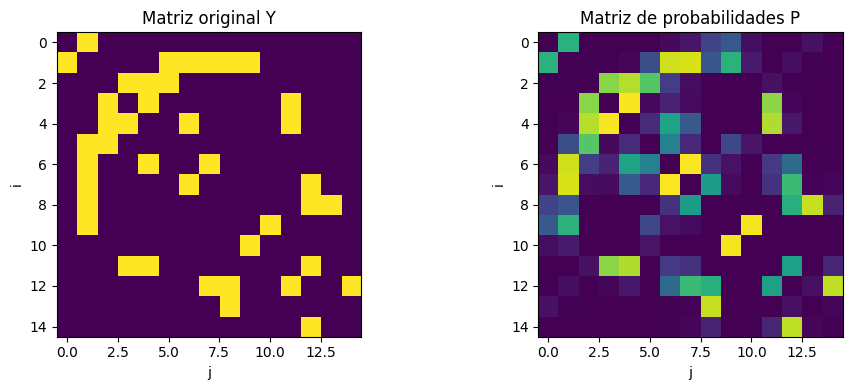

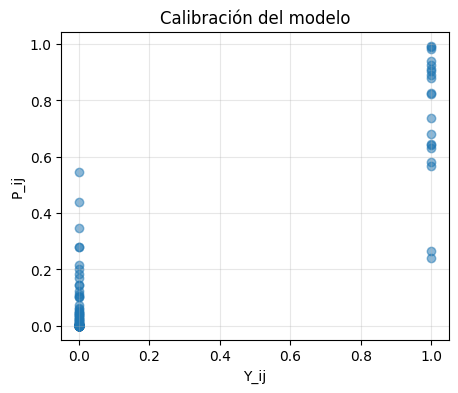

In [71]:

geometry = HyperbolicGeometry(d=2, D=jnp.pi)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference( model, lr=1e-6)
result = inference.fit_multi_start(n_starts=2,n_iter=50000, tol=1e-13, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

Modelo hiperbólico sin pesos

MAP:   0%|          | 0/50000 [00:00<?, ?it/s]

MAP: 100%|██████████| 50000/50000 [03:13<00:00, 257.78it/s, logpost=-59.7904, loglik=-58.6342, logprior=-1.1562, patience=0]



Best log-posterior: -59.7904

Log-posterior final: -59.790443420410156
alpha0: 0.3137942
xi: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Z: [[ 1.4459348  -0.4667095   1.8189152 ]
 [ 1.116893   -0.02635584  1.4993798 ]
 [-0.06719771  0.36887264  1.06798   ]
 [-0.16377625  2.295464    2.5091786 ]
 [-0.63300025  2.2125297   2.5091786 ]
 [ 0.95850503 -0.63530517  1.523894  ]
 [-0.55796015  0.02045299  1.1453063 ]
 [-0.07518764 -0.37125707  1.0690583 ]
 [-0.46716684  0.5446083   1.2307997 ]
 [-0.14316379  0.05529171  1.0116811 ]
 [-0.7652096   0.24632622  1.2830384 ]
 [-0.10191823  0.15402941  1.016912  ]
 [-0.55904055  0.4412797   1.2277213 ]
 [-0.03970456  0.01781327  1.0009887 ]
 [ 0.07922745 -0.03786575  1.0038049 ]]


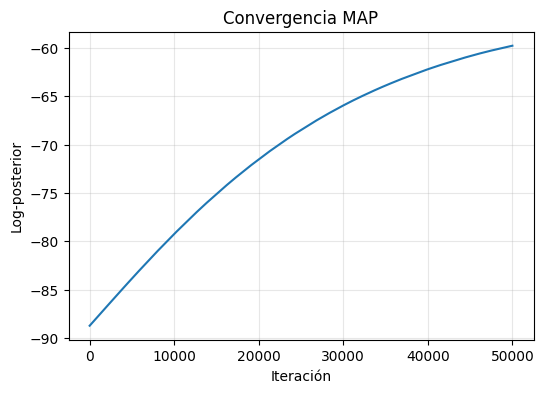

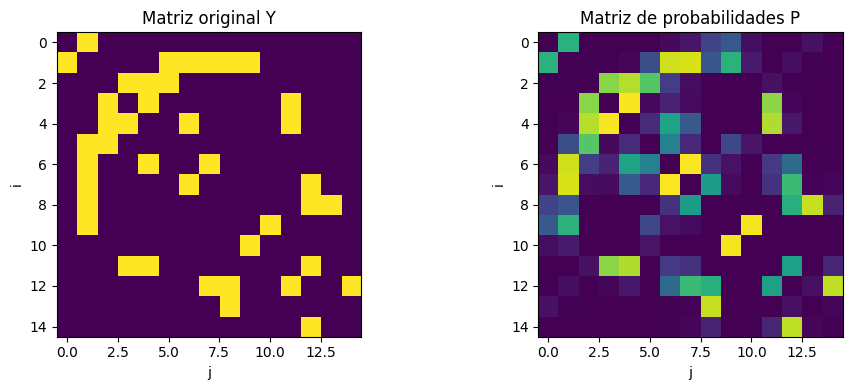

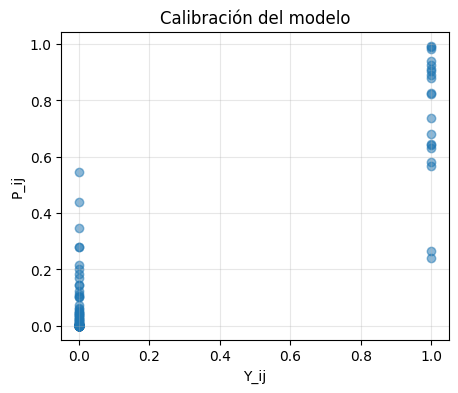

In [70]:

geometry = HyperbolicGeometry(d=2, D=jnp.pi)

model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi":jnp.ones(15)})
inference = MAPInference( model, lr=1e-6)
result = inference.fit_multi_start(n_starts=2,n_iter=50000, tol=1e-13, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

#### MCMC

In [ ]:
class MCMCInference(BaseInference):
    def __init__(self, model, eps_alpha0=1e-2, eps_xi=1e-2, eps_Z=1e-2, target_accept_alpha0=0.57, target_accept_xi=0.57, target_accept_Z=0.5):
        super().__init__(model)
        self.eps_alpha0 = eps_alpha0
        self.eps_xi = eps_xi
        self.eps_Z = eps_Z
        self.target_alpha0 = target_accept_alpha0
        self.target_xi = target_accept_xi
        self.target_Z = target_accept_Z

        self.geometry = self.model.geometry

        self.model.inference_method = "MCMC"
    
    # Log q
    def _log_q(self, x_new, x, grad_x, eps):
        mean = x + 0.5 * eps**2 * grad_x
        diff = x_new - mean
        return -0.5 * jnp.sum(diff**2) / (eps**2)

    def _log_q_manifold(self, z_new, z, grad_z, eps):
        v = jax.vmap(self.geometry.logaritmic_map)(z, z_new)
        mean = 0.5 * eps**2 * grad_z
        diff = v - mean
        return -0.5 * jnp.sum(diff**2) / (eps**2)

    # Adapt step size (Robbins–Monro)
    def _adapt(self, eps, accept, target, t):
        gamma = (t + 1) ** (-0.6)
        log_eps = jnp.log(eps) + gamma * (accept - target)
        return jnp.exp(log_eps)

    # Steps
    def step_alpha0(self, key):
        eps = self.eps_alpha0
        p = self.model.get_params()
        alpha0 = p["alpha0"]
        grad = self.model.grad_log_posterior()["alpha0"]
        key1, key2 = jax.random.split(key)
        noise = jax.random.normal(key1)
        prop = alpha0 + 0.5 * eps**2 * grad + eps * noise
        logp_current = self.model.log_posterior()
        self.model.latent_params["alpha0"] = prop
        logp_prop = self.model.log_posterior()
        grad_prop = self.model.grad_log_posterior()["alpha0"]
        log_q_f = self._log_q(prop, alpha0, grad, eps)
        log_q_b = self._log_q(alpha0, prop, grad_prop, eps)
        log_accept = logp_prop + log_q_b - logp_current - log_q_f
        if jnp.log(jax.random.uniform(key2)) < log_accept:
            return 1.0
        else:
            self.model.latent_params["alpha0"] = alpha0
            return 0.0

    def step_xi(self, key):
        eps = self.eps_xi
        p = self.model.get_params()
        xi = p["xi"]
        grad = self.model.grad_log_posterior()["xi"]
        simplex = self.model.weights
        grad = simplex.project_to_tangent(xi, grad)
        key1, key2 = jax.random.split(key)
        noise = jax.random.normal(key1, shape=xi.shape)
        noise = simplex.project_to_tangent(xi, noise)
        v = 0.5 * eps**2 * grad + eps * noise
        xi_prop = simplex.exponential_map(xi, v)
        xi_prop = simplex.project_to_domain(xi_prop)
        logp_current = self.model.log_posterior()
        self.model.latent_params["xi"] = xi_prop
        logp_prop = self.model.log_posterior()
        grad_prop = self.model.grad_log_posterior()["xi"]
        grad_prop = simplex.project_to_tangent(xi_prop, grad_prop)
        log_q_f = self._log_q(xi_prop, xi, grad, eps)
        log_q_b = self._log_q(xi, xi_prop, grad_prop, eps)
        log_accept = logp_prop + log_q_b - logp_current - log_q_f
        if jnp.log(jax.random.uniform(key2)) < log_accept:
            return 1.0
        else:
            self.model.latent_params["xi"] = xi
            return 0.0
        
    def step_Z(self, key):
        eps = self.eps_Z
        geom = self.model.geometry
        Z = self.model.get_params()["Z"]
        n = Z.shape[0]
        keys = jax.random.split(key, n)
        accepted = 0.0
        for i in range(n):
            zi = Z[i]
            grad = self.model.grad_log_posterior()["Z"][i]
            grad = geom.project_to_tangent(zi, grad)
            key1, key2 = jax.random.split(keys[i])
            noise = jax.random.normal(key1, shape=zi.shape)
            noise = geom.project_to_tangent(zi, noise)
            v = 0.5 * eps**2 * grad + eps * noise
            zi_prop = geom.exponential_map(zi, v)
            zi_prop = geom.project_to_domain(zi_prop)
            Z_prop = Z.at[i].set(zi_prop)
            logp_current = self.model.log_posterior()
            self.model.latent_params["Z"] = Z_prop
            logp_prop = self.model.log_posterior()
            grad_prop = self.model.grad_log_posterior()["Z"][i]
            grad_prop = geom.project_to_tangent(zi_prop, grad_prop)
            log_q_f = self._log_q_manifold(zi_prop, zi, grad, eps)
            log_q_b = self._log_q_manifold(zi, zi_prop, grad_prop, eps)
            log_accept = logp_prop + log_q_b - logp_current - log_q_f
            if jnp.log(jax.random.uniform(key2)) < log_accept:
                Z = Z_prop
                accepted += 1.0
            else:
                self.model.latent_params["Z"] = Z
        self.model.latent_params["Z"] = Z
        return accepted / n

    def fit(self, n_samples=1000, burnin=1000, thin=1, seed=0, verbose=True, Z_ref=None, init_params={}):
        if init_params:
            self.model.latent_params = {
                k: v for k, v in init_params.items()
                if k not in self.model.fixed_params
            }
        else:
            self.model.initialize_from_prior(
                n=self.model.Y.shape[0],
                seed=seed
            )

        key = jax.random.PRNGKey(seed)
        total_iters = burnin + n_samples * thin
        samples = []
        self.history = {"logpost": [], "loglik": [], "logprior": [],
                        "eps": {"alpha0": [], "xi": [], "Z": []}, 
                        "acceptance": {"alpha0": [], "xi": [], "Z": []}}
        self.Z_ref = Z_ref
        self._Z_ref_initialized = Z_ref is not None
        

        iterator = tqdm(range(total_iters), desc="MCMC") if verbose else range(total_iters)
        for t in iterator:
            key, subkey = jax.random.split(key)
            k1, k2, k3 = jax.random.split(subkey, 3)
            acc_a = self.step_alpha0(k1) if "alpha0" in self.model.latent_params else 1.0
            acc_x = self.step_xi(k2) if "xi" in self.model.latent_params else 1.0
            acc_z = self.step_Z(k3) if "Z" in self.model.latent_params else 1.0

            if (not self._Z_ref_initialized) and (t == burnin):
                self.Z_ref = self.model.get_params()["Z"]
                self._Z_ref_initialized = True

            if self._Z_ref_initialized:
                Z = self.model.latent_params["Z"]
                Z = self.geometry.identifiability_transform(Z, self.Z_ref)
                self.model.latent_params["Z"] = Z


            self.history["acceptance"]["alpha0"].append(float(acc_a))
            self.history["acceptance"]["xi"].append(float(acc_x))
            self.history["acceptance"]["Z"].append(float(acc_z))

            if t < burnin:
                self.eps_alpha0 = self._adapt(self.eps_alpha0, acc_a, self.target_alpha0, t)
                self.eps_xi     = self._adapt(self.eps_xi, acc_x, self.target_xi, t)
                self.eps_Z      = self._adapt(self.eps_Z, acc_z, self.target_Z, t)
            loglik = self.model.log_likelihood()
            logprior = self.model.log_prior()
            logpost = loglik + logprior  #self.model.log_posterior()
            self.history["loglik"].append(float(loglik))
            self.history["logprior"].append(float(logprior))
            self.history["logpost"].append(float(logpost))
            self.history["eps"]["alpha0"].append(float(self.eps_alpha0))
            self.history["eps"]["xi"].append(float(self.eps_xi))
            self.history["eps"]["Z"].append(float(self.eps_Z))


            if t >= burnin and ((t - burnin) % thin == 0):
                samples.append({ k: v.copy() if hasattr(v, "copy") else v for k, v in self.model.get_params().items()})
            if verbose:
                acc_total = 0.0
                acc_total += np.mean(np.array(self.history["acceptance"]["alpha0"]))
                acc_total += np.mean(np.array(self.history["acceptance"]["xi"]))
                acc_total += np.mean(np.array(self.history["acceptance"]["Z"]))
                acc_total /= 3
                iterator.set_postfix({"logpost": f"{logpost:.3f}", "loglik": f"{loglik:.3f}", "logprior": f"{logprior:.3f}",
                                       "acceptance": f"{acc_total:.3f}"})

        self.samples = samples
        return samples

In [ ]:

geometry = EuclideanGeometry(d=2, D=25.0)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MCMCInference(model)
result = inference.fit(n_samples=1000, burnin=1000, thin=1)

MCMC: 100%|██████████| 2000/2000 [06:13<00:00,  5.36it/s, logpost=-31.516, loglik=-27.113, logprior=-4.403, acceptance=0.570] 


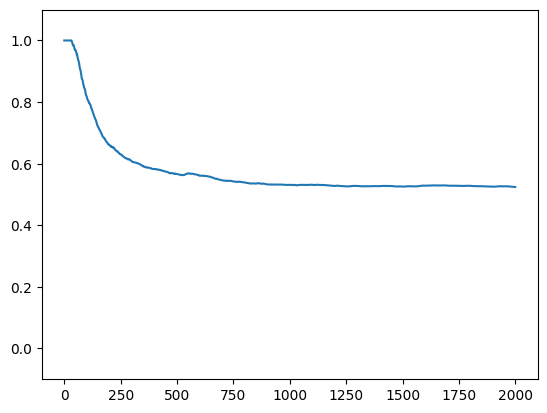

In [31]:
plt.plot(jnp.cumulative_sum(jnp.array(inference.history['acceptance']['Z'])) / jnp.array(range(1,2001)))
plt.ylim(-0.1,1.1)
plt.show()

In [ ]:
plt.hist(np.array([result[l]['xi'] for l in range(1000)])[:,1],bins=50)
plt.show()

### Analysis

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

### Model $\mathbb{R}^2$

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

### Model $\mathbb{S}^2$

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

### Model $\mathbb{H}^2$